# Amazon Scaping Laptops Data

In [1]:
# install beautifulsoup4 and requests
!pip install beautifulsoup4 requests

In [1]:
# import required libraries
import requests
from bs4 import BeautifulSoup
import re
import pandas as pd


In [3]:
# url of the page to be scraped
url ="https://www.amazon.in/s?k=laptops&crid=3O5DJEZW2W1BU&sprefix=lapto%2Caps%2C809&ref=nb_sb_noss_2"

In [4]:
# make header to mimic a browser visit
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/137.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9"
}

In [5]:
# check if the url is accessible
response = requests.get(url, headers=headers)
if response.status_code == 200:
    print("URL is accessible")
else:
    print("URL is not accessible")    

In [6]:
# check the response content
print(response.content)

In [7]:
# convert the response content to a BeautifulSoup object
soup = BeautifulSoup(response.content, "html.parser")
soup

In [8]:
# create the empty lists to store the scraped data
data = []
print("Data cleared")

In [9]:
for page in range(1,50):

    #paramters to be sent in the get request
    params = {
        "k": "laptops",
        "page": page
    }

    # get response from the server
    response = requests.get(url, headers=headers, params=params)

    # convert the response content to a BeautifulSoup object
    soup = BeautifulSoup(response.content, "html.parser")

    # find all the product items on the page using correct selector
    product_containers = soup.find_all("div", class_="s-result-item")

    # extract the required data from each product container
    for container in product_containers:

        # Step 1: Extract title from h2 tag
        h2_tag = container.find("h2")
        if not h2_tag:
            continue
        
        title = h2_tag.text.strip()
        
        # Skip if title is too short or is a header
        if len(title) < 10 or title in ["Results", "Trending now"]:
            continue

        # Step 2: Extract product price
        price_tag = container.find("span", class_="a-price-whole")
        price = price_tag.text.strip() if price_tag else "N/A"

        # Step 3: Extract product brand (first word)
        match = re.search(r"^([A-Za-z]+)", title)
        brand = match.group(1) if match else "Unknown"

        # Step 4 : Extract the ram form the title using regex GB,ram DDR LPDDR
        match = re.search(r"(\d+GB|RAM\s*(\d+GB)?|DDR\d?\s*(\d+GB)?|LPDDR\d?\s*(\d+GB)?)", title, re.IGNORECASE)
        ram = match.group(1) if match else "N/A"

        # Step 5 : Extract the SSD storage from the title using reges
        match = re.search(r"(\d+)\s*(GB|TB)\s*(?:SSD|Storage|HDD)", title, re.IGNORECASE)
        ssd_storage = f"{match.group(1)}{match.group(2)}" if match else "N/A"
        
        #Step 6 : Extract the Color from the title using regex
        match = re.search(r"\b(Black|White|Silver|Gray|Grey|Red|Blue|Green|Yellow|Pink|Purple|Gold|Bronze|Rose Gold|Indigo|Glacier)\b", title, re.IGNORECASE)
        color = match.group(1) if match else "N/A"

        # Step 7: Extract the processor (Intel, AMD, Apple M/A chip, Snapdragon, MediaTek, etc)
        processor = "N/A"
        # Try to match Apple M series (M1, M2, M3, M4, M5, etc.)
        match = re.search(r"Apple\s+M(\d+)", title, re.IGNORECASE)
        if match:
            processor = f"Apple M{match.group(1)}"
        else:
            # Try to match Apple A series (A18, A17, A16, etc.)
            match = re.search(r"Apple\s+A(\d+)", title, re.IGNORECASE)
            if match:
                processor = f"Apple A{match.group(1)}"
            else:
                # Try other processor keywords
                processor_keywords = ["Intel", "AMD", "Snapdragon", "MediaTek", "Celeron"]
                for keyword in processor_keywords:
                    if re.search(rf"\b{keyword}\b", title, re.IGNORECASE):
                        processor = keyword
                        break
        
        # Step 8: Extract the OS from the title using regex
        os = "N/A"
        # Check for MacBook/macOS first (Apple specific)
        if re.search(r"\b(MacBook|macOS|Mac OS)\b", title, re.IGNORECASE):
            os = "MacOS"
        # Check for Apple processors (M or A series means MacOS)
        elif re.search(r"\bApple\s+[MA]\d+\b", title, re.IGNORECASE):
            os = "MacOS"
        # Check for Windows variations
        elif re.search(r"\b(Windows|Win\s*11|Win11|Win\s*10|Win10)\b", title, re.IGNORECASE):
            os = "Windows"
        # Check for other OS keywords
        else:
            OS_keywords = ["Linux", "Chrome OS", "Android", "iOS"]
            for keyword in OS_keywords:
                if re.search(rf"\b{keyword}\b", title, re.IGNORECASE):
                    os = keyword
                    break
            
        # Step 9: Extract the Rating from the container
        rating = "N/A"
        # Try multiple methods to find rating
        # Method 1: Look for i-star span
        rating_span = container.find("span", class_=lambda x: x and "i-star" in str(x).lower() if x else False)
        
        # Method 2: Look for aria-label attribute with rating
        if not rating_span:
            rating_span = container.find("span", {"aria-label": lambda x: x and "out of 5" in str(x).lower() if x else False})
        
        # Method 3: Look for a-icon-star class
        if not rating_span:
            rating_span = container.find("i", class_=lambda x: x and "a-icon-star" in str(x).lower() if x else False)
        
        if rating_span:
            # Try to get rating from aria-label
            aria_label = rating_span.get("aria-label")
            if aria_label:
                match = re.search(r"(\d+\.?\d*)\s*out of 5", aria_label)
                if match:
                    rating = match.group(1)
            else:
                # Try to get from text
                rating_text = rating_span.text.strip() if rating_span else ""
                match = re.search(r"(\d+\.?\d*)", rating_text)
                if match:
                    rating = match.group(1) 


        # Append the extracted data to the list
        data.append({
            "title": title,
            "price": price,
            'brand' : brand,
            'ram' : ram,
            'ssd_storage' : ssd_storage,
            'color' : color,
            'processor' : processor,
            'os' : os,
            'rating' : rating
        })

print("Total items scraped:", len(data))


In [10]:
# print the scraped data in a structured format
for item in data:
    print(f"Title: {item['title']}")
    print(f"Price: {item['price']}")
    print(f"Brand: {item['brand']}")
    print(f"RAM: {item['ram']}")
    print(f"SSD Storage: {item['ssd_storage']}")
    print(f"Color: {item['color']}")
    print(f"Processor: {item['processor']}")
    print(f"OS: {item['os']}")
    print(f"Rating: {item['rating']}")
    print("-" * 40)

In [11]:
# make the dataframe from the scraped data
df = pd.DataFrame(data)
df.head()

In [ ]:
# saved dataset to csv file
df.to_csv("amazon_laptops.csv", index=False)

In [2]:
# 

df  = pd.read_csv("amazon_laptops.csv")
df.head()

,Price,Brand,RAM,SSD_Storage,Color,Processor,OS,Rating
0,"53,990",Acer,12GB,512.0,Silver,Intel,Windows,4.0
1,"79,990",Acer,16GB,512.0,Grey,NaN,Windows,NaN
2,"45,490",Dell,8GB,NaN,Black,Intel,Windows,4.1
3,"51,990",HP,8GB,512.0,Silver,Intel,Windows,4.1
4,"53,990",ASUS,8GB,NaN,Blue,Intel,Windows,NaN


# Data Preprocessing on the scrap data

In [3]:
# check the info of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1069 entries, 0 to 1068
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Price        921 non-null    object 
 1   Brand        1069 non-null   object 
 2   RAM          789 non-null    object 
 3   SSD_Storage  744 non-null    float64
 4   Color        740 non-null    object 
 5   Processor    704 non-null    object 
 6   OS           795 non-null    object 
 7   Rating       838 non-null    float64
dtypes: float64(2), object(6)
memory usage: 66.9+ KB


In [4]:
# check the shape of the dataframe
df.shape

(1069, 8)

In [5]:
# check the missing values in the dataframe
df.isnull().sum()

Price          148
Brand            0
RAM            280
SSD_Storage    325
Color          329
Processor      365
OS             274
Rating         231
dtype: int64

In [6]:
# replace all N/A values with NaN
df.replace("N/A", pd.NA, inplace=True)

In [7]:
# check missing value 
df.isnull().sum()

Price          148
Brand            0
RAM            280
SSD_Storage    325
Color          329
Processor      365
OS             274
Rating         231
dtype: int64

In [8]:
#  drop the title column as it is not required for analysis
df.drop("title", axis=1, inplace=True)

KeyError: "['title'] not found in axis"

In [ ]:
df.head()

,Price,Brand,RAM,SSD_Storage,Color,Processor,OS,Rating
0,"53,990",Acer,12GB,512.0,Silver,Intel,Windows,4.0
1,"79,990",Acer,16GB,512.0,Grey,NaN,Windows,NaN
2,"45,490",Dell,8GB,NaN,Black,Intel,Windows,4.1
3,"51,990",HP,8GB,512.0,Silver,Intel,Windows,4.1
4,"53,990",ASUS,8GB,NaN,Blue,Intel,Windows,NaN


In [ ]:
# all columns are first letter title 
df.columns = df.columns.str.title()

In [ ]:
df.head()

,Price,Brand,Ram,Ssd_Storage,Color,Processor,Os,Rating
0,"53,990",Acer,12GB,512.0,Silver,Intel,Windows,4.0
1,"79,990",Acer,16GB,512.0,Grey,NaN,Windows,NaN
2,"45,490",Dell,8GB,NaN,Black,Intel,Windows,4.1
3,"51,990",HP,8GB,512.0,Silver,Intel,Windows,4.1
4,"53,990",ASUS,8GB,NaN,Blue,Intel,Windows,NaN


In [ ]:
# Rename multiple columns
df = df.rename(columns = {'Ram' : 'RAM', 'Ssd_Storage' : 'SSD_Storage', 'Os' : 'OS',})

In [ ]:
df.head()

,Price,Brand,RAM,SSD_Storage,Color,Processor,OS,Rating
0,"53,990",Acer,12GB,512.0,Silver,Intel,Windows,4.0
1,"79,990",Acer,16GB,512.0,Grey,NaN,Windows,NaN
2,"45,490",Dell,8GB,NaN,Black,Intel,Windows,4.1
3,"51,990",HP,8GB,512.0,Silver,Intel,Windows,4.1
4,"53,990",ASUS,8GB,NaN,Blue,Intel,Windows,NaN


In [ ]:
df.head()

,Price,Brand,RAM,SSD_Storage,Color,Processor,OS,Rating
0,"53,990",Acer,12GB,512.0,Silver,Intel,Windows,4.0
1,"79,990",Acer,16GB,512.0,Grey,NaN,Windows,NaN
2,"45,490",Dell,8GB,NaN,Black,Intel,Windows,4.1
3,"51,990",HP,8GB,512.0,Silver,Intel,Windows,4.1
4,"53,990",ASUS,8GB,NaN,Blue,Intel,Windows,NaN


In [9]:
# handled the SSD storage column 

# replace the 1TB with 1024GB in the SSD storage column
df['SSD_Storage'] = df['SSD_Storage'].astype(str).str.replace('1TB', '1024GB', regex=False)

# replace GB with empty string and convert to numeric
df['SSD_Storage'] = df['SSD_Storage'].str.replace('GB', '', regex=False)
df['SSD_Storage'] = pd.to_numeric(df['SSD_Storage'], errors='coerce')
df['SSD_Storage']

0        512.0
1        512.0
2          NaN
3        512.0
4          NaN
         ...  
1064    1024.0
1065    1024.0
1066       NaN
1067       NaN
1068       NaN
Name: SSD_Storage, Length: 1069, dtype: float64

In [10]:
# Remove the RAM Column of GB
df['RAM'] = df['RAM'].str.replace('GB', '', regex=False)
df['RAM'] = pd.to_numeric(df['RAM'], errors='coerce')

In [11]:
# covert the RAM into Integer
df['RAM'] = df['RAM'].astype('Int64')
df['RAM']

0         12
1         16
2          8
3          8
4          8
        ... 
1064      32
1065      24
1066    <NA>
1067    <NA>
1068    <NA>
Name: RAM, Length: 1069, dtype: Int64

In [12]:
df.head()

,Price,Brand,RAM,SSD_Storage,Color,Processor,OS,Rating
0,"53,990",Acer,12,512.0,Silver,Intel,Windows,4.0
1,"79,990",Acer,16,512.0,Grey,NaN,Windows,NaN
2,"45,490",Dell,8,NaN,Black,Intel,Windows,4.1
3,"51,990",HP,8,512.0,Silver,Intel,Windows,4.1
4,"53,990",ASUS,8,NaN,Blue,Intel,Windows,NaN


In [13]:
# check the missing value 
df.isnull().sum()

Price          148
Brand            0
RAM            298
SSD_Storage    325
Color          329
Processor      365
OS             274
Rating         231
dtype: int64

In [14]:
# Convert SSD storage and RAM to Integer
df['SSD_Storage'] = df['SSD_Storage'].astype('Int64')


In [15]:
# check the datatype of the columns
df.dtypes

Price           object
Brand           object
RAM              Int64
SSD_Storage      Int64
Color           object
Processor       object
OS              object
Rating         float64
dtype: object

In [16]:
# Price column convert into integer
df['Price'] = df['Price'].str.replace(',', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')



In [17]:
# convert the price column into integer
df['Price'] = df['Price'].astype('Int64')

In [18]:
# Head of the dataframe after cleaning
df.head()

,Price,Brand,RAM,SSD_Storage,Color,Processor,OS,Rating
0,53990,Acer,12,512,Silver,Intel,Windows,4.0
1,79990,Acer,16,512,Grey,NaN,Windows,NaN
2,45490,Dell,8,<NA>,Black,Intel,Windows,4.1
3,51990,HP,8,512,Silver,Intel,Windows,4.1
4,53990,ASUS,8,<NA>,Blue,Intel,Windows,NaN


In [19]:
#find the percentage of missing values in each column
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(round(missing_percentage, 2))

Price          13.84
Brand           0.00
RAM            27.88
SSD_Storage    30.40
Color          30.78
Processor      34.14
OS             25.63
Rating         21.61
dtype: float64


In [20]:
# check the categorical columns and their unique values
categorical_columns = df.select_dtypes(include=['object']).columns

for column in categorical_columns:
    unique_values = df[column].unique()
    print(f"Column: {column}")
    print(f"Unique Values: {unique_values}")
    

Column: Brand
Unique Values: ['Acer' 'Dell' 'HP' 'ASUS' 'Lenovo' 'Primebook' 'More' 'BKN' 'Apple'
 'EBook' 'MSI' 'Unknown' 'COSMUS' 'Related' 'Need' 'Highly' 'acer'
 'Alienware' 'DELL' 'Samsung' 'TABLE' 'DELLMODEL' 'Thomson']
Column: Color
Unique Values: ['Silver' 'Grey' 'Black' 'Blue' 'Glacier' 'Gray' nan 'Indigo' 'Gold']
Column: Processor
Unique Values: ['Intel' nan 'Snapdragon' 'MediaTek' 'AMD' 'Celeron']
Column: OS
Unique Values: ['Windows' 'Android' nan 'MacOS' 'Chrome OS']


In [21]:
# statistical summary of the numerical columns
df.describe()

,Price,RAM,SSD_Storage,Rating
count,921.0,771.0,744.0,838.000000
mean,77413.456026,15.315175,638.967742,3.974463
std,59864.111017,5.757707,232.905018,0.614863
min,267.0,4.0,128.0,1.000000
25%,58990.0,12.0,512.0,4.000000
50%,67990.0,16.0,512.0,4.200000
75%,79990.0,16.0,1024.0,4.200000
max,522990.0,64.0,1024.0,5.000000


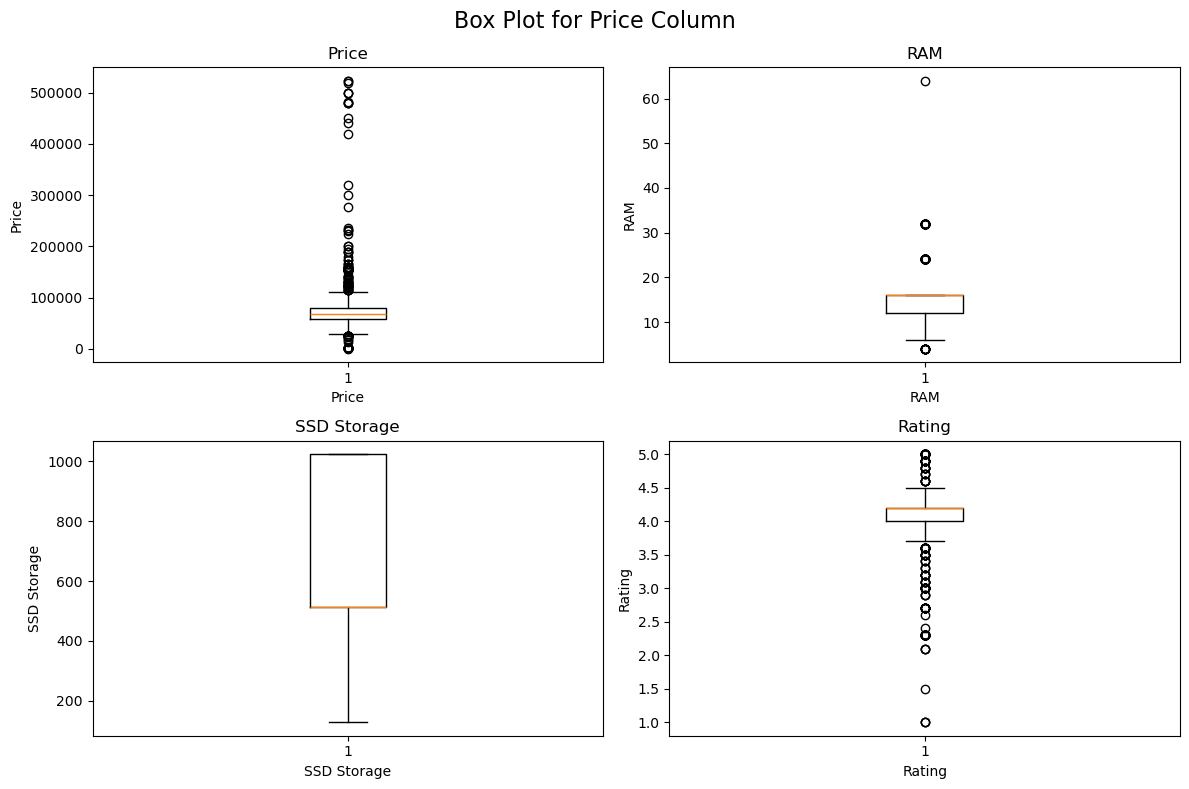

In [22]:
# make the box plot for the price column
import matplotlib.pyplot as plt

# make the subplot
fig,axes = plt.subplots(2,2, figsize=(12,8))

# make the title of the subplot
fig.suptitle("Box Plot for Price Column", fontsize=16)

# make the box plot for the price column
axes[0,0].boxplot(df['Price'].dropna())
axes[0,0].set_title("Price")
axes[0,0].set_xlabel("Price")
axes[0,0].set_ylabel("Price")


axes[0,1].boxplot(df['RAM'].dropna())
axes[0,1].set_title("RAM")
axes[0,1].set_xlabel("RAM")
axes[0,1].set_ylabel("RAM")

axes[1,0].boxplot(df['SSD_Storage'].dropna())
axes[1,0].set_title("SSD Storage")
axes[1,0].set_xlabel("SSD Storage")
axes[1,0].set_ylabel("SSD Storage")

axes[1,1].boxplot(df['Rating'].dropna())
axes[1,1].set_title("Rating")
axes[1,1].set_xlabel("Rating")
axes[1,1].set_ylabel("Rating")

plt.tight_layout()
plt.show()



In [23]:
# handled the missing value with median for three columns price ,ram ,rating  and ssd with mean 

# find the median for the price columns 


df['Price'] = df['Price'].fillna(df['Price'].median(),axis = 0)

df['RAM']  = df['RAM'].fillna(df['RAM'].median(),axis = 0)

df['Rating'] = df['Rating'].fillna(df['Rating'].median(),axis = 0)

df['SSD_Storage'] = df['SSD_Storage'].fillna(int(round(df['SSD_Storage'].mean())), axis=0)

In [24]:
# check the missing value after the handled 
df.isnull().sum()

Price            0
Brand            0
RAM              0
SSD_Storage      0
Color          329
Processor      365
OS             274
Rating           0
dtype: int64